# Проект модуля. Нейросеть для предсказания калорийности блюд
## репозиторий проекта здесь:
https://github.com/SanSanychSeva/Yandex_Practicum_DL_Engineer_2026_stream4


In [475]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from gensim.models import KeyedVectors

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torchvision.transforms.functional import pil_to_tensor

from scripts.nlp_feature_extraction import get_text_embedding

# Метаданные

## флаги отладки

## глобальные параметры

In [476]:
# файловая структура проекта
dataset_dir = os.path.join( 'data','project')                # датасет не копируется в репозиторий из-за ограничений GitHub
word2vec_path = os.path.join('models','word2vec-google-news-300.gz')           # предзагруженная модель векторизации текста

# параметры обучения
target_mae = 50                                 # целевая точность моделей

# Этап 1. EDA исходного датасета 

## `images` - папки с фото блюд

In [477]:
dish_list = os.listdir(os.path.join(dataset_dir,'images'))

print('FYI: всего папок с фото блюд', len(dish_list), ', примеры названий папок:\n', dish_list[:5])

FYI: всего папок с фото блюд 3490 , примеры названий папок:
 ['dish_1556572657', 'dish_1556573514', 'dish_1556575014', 'dish_1556575083', 'dish_1556575124']


### проверим, по скольку фото на одно блюдо присутствует в датасете

In [478]:
nof_photos = []
for dish in dish_list:
    nof_photos.append(
        len(os.listdir(os.path.join(dataset_dir, 'images', dish)))
    )

pd.Series(nof_photos).value_counts(dropna=False)

1    3490
Name: count, dtype: int64

### проверим разрешение всех файлов

In [479]:
photo_shapes = []
photo_samples = []
for dish in tqdm(dish_list):
    f_name = os.listdir(os.path.join(dataset_dir, 'images', dish))[0]
    img = Image.open(os.path.join(dataset_dir, 'images', dish, f_name)).convert("RGB")
    photo_shapes.append(np.array(img).shape)
    if np.random.choice([1]+[0]*(len(dish_list)//10)):  # берем вероятность так, чтобы выбрать примерно 10 блюд для показа
        photo_samples.append((dish, img))

pd.Series(photo_shapes).value_counts(dropna=False)

100%|██████████| 3490/3490 [00:23<00:00, 147.57it/s]


(480, 640, 3)    3490
Name: count, dtype: int64

**ВЫВОДЫ:**
* на одно блюдо в датасете строго одно фото
* все фото имеют одинаковый размер массива пикселей (480, 640, 3) - (H, W, C)

### посмотрим на случайно выбранные картинки блюд

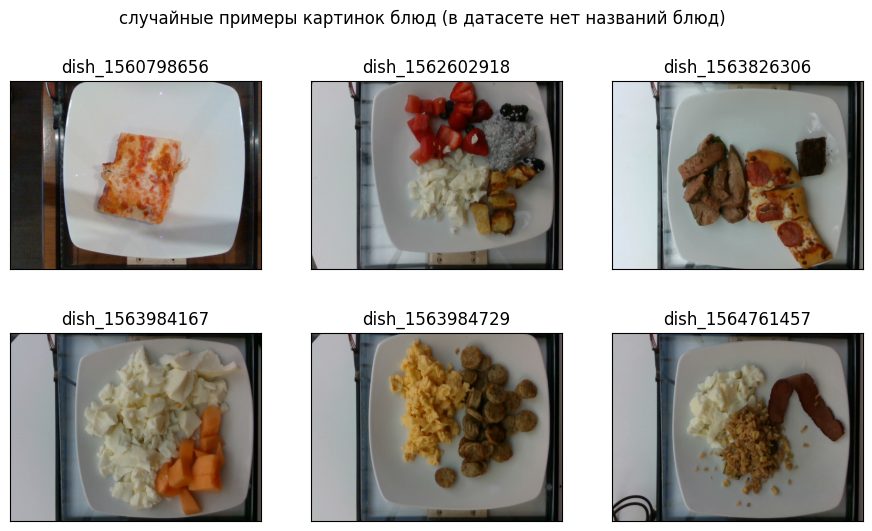

In [480]:
fig, axes = plt.subplots(2,3, figsize=(11,6))
axes = axes.flatten()

for i,ax in enumerate(axes):
    if i < len(photo_samples):
        ax.imshow(photo_samples[i][1])
        ax.set_title(photo_samples[i][0])
    ax.set_xticks([])
    ax.set_yticks([])
    
fig.suptitle('случайные примеры картинок блюд (в датасете нет названий блюд)')
plt.show()

## `dish.csv` - список блюд

In [481]:
# сразу зафиксируем порядок записей в таблице блюд (в том числе, удобным для train-test-split образом):
dish_df = pd.read_csv(os.path.join(dataset_dir,'dish.csv')).sort_values(['split','dish_id']).reset_index(drop=True)

dish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


**НАБЛЮДЕНИЕ:** записей меньше, чем папок

In [482]:
dish_df.sample(5, axis=0)

,dish_id,total_calories,total_mass,ingredients,split
1788,dish_1562183151,108.392403,195.0,ingr_0000000161;ingr_0000000201;ingr_000000031...,train
2886,dish_1565987054,260.569977,213.0,ingr_0000000036;ingr_0000000028,train
200,dish_1561405389,265.983459,223.0,ingr_0000000026;ingr_0000000187;ingr_000000050...,test
1507,dish_1561576295,249.067139,232.0,ingr_0000000094;ingr_0000000031;ingr_000000003...,train
1934,dish_1562775488,91.239998,145.0,ingr_0000000128;ingr_0000000437,train


**НАБЛЮДЕНИЕ:** значения `dish_id` похожи на именования папок с фото блюд

In [483]:
dish_df.dish_id.value_counts(dropna=False).head()         # проверим уникальность dish_id (все частоты в топе равны 1)

dish_id
dish_1556575327    1
dish_1563294522    1
dish_1563221640    1
dish_1563222745    1
dish_1563222775    1
Name: count, dtype: int64

### а все ли блюда есть в списках и на фото?

In [484]:
counter = 0

for dish in list(dish_df.dish_id):
    if dish not in dish_list:
        counter += 1

if counter == 0:
    print('FYI: All dishes in dish.csv(field "dish_id") are present in dish dir list')
else:
    print('FYI:', counter, 'out of', len(dish_df), 'dishes in dish.csv(field "dish_id") are missing in dish dir list')

counter = 0

for dish in dish_list:
    if dish not in list(dish_df.dish_id):
        counter += 1

if counter == 0:
    print('FYI: All dishes in dish dir list are present in dish.csv(field "dish_id")')
else:
    print('FYI:', counter, 'out of', len(dish_list), 'dishes in dish dir list are missing in dish.csv(field "dish_id")')

FYI: All dishes in dish.csv(field "dish_id") are present in dish dir list
FYI: 228 out of 3490 dishes in dish dir list are missing in dish.csv(field "dish_id")


In [485]:
len(dish_df) + counter,  len(dish_list)     # проверяем возможные причины - должны совпасть!

(3490, 3490)

**ВЫВОДЫ:**
* 228 папок с фото лишние в датасете - для них нет информации в списке блюд
* для всех блюд в списке есть папка с фото (поэтому лишние фото не помешают строить детесет, исходя из списка блюд)

## `ingredients.csv` - список ингредиентов

In [486]:
ingr_df = pd.read_csv(os.path.join(dataset_dir,'ingredients.csv')).sort_values('id').reset_index(drop=True)

ingr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


In [487]:
ingr_df.head()

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [488]:
ingr_df.id.value_counts(dropna=False).head()                 # проверим уникальность id (все частоты в топе равны 1)

id
1      1
373    1
367    1
368    1
369    1
Name: count, dtype: int64

### ID ингредиентов имеют разный формат в двух таблицах, проверим предполагаемое мнемоническое правило:
если в поле `ingredients` списка блюд отбросить все знаки левее первой отличной от нуля цифры, то получим целый ID из `indredients.csv` колонка `id`

In [489]:
dish_df['dish_ingr_list'] = dish_df.ingredients.map(lambda s: s.strip().split(';'))   # конвертим строку в список

In [490]:
dish_df.dish_ingr_list = dish_df.dish_ingr_list.map(pd.Series).map(                       # конвертим список в серию пандас
                            lambda ser: ser.map(                                          # к каждой серии применяем map()
                                lambda s: int(re.sub(r"^0+", "", re.sub(r"\D", "", s)))   # с регулярным выражением и 
                            )                                                             # конвертим остаток в целый тип
                        ).map(list)                                                       # возвращаем тип список (целых)

**NB!:** теперь предполагается, что поле `dish_ingr_list` содержит списки целочисленных ID ингредиентов из таблицы таковых (поле `id`)

In [491]:
dish_df.sample(5, axis=0)

,dish_id,total_calories,total_mass,ingredients,split,dish_ingr_list
1192,dish_1560366998,39.600002,131.0,ingr_0000000112;ingr_0000000471,train,"[112, 471]"
2720,dish_1565378731,154.358154,207.0,ingr_0000000514;ingr_0000000045;ingr_000000029...,train,"[514, 45, 291, 312, 161]"
1872,dish_1562689645,302.431702,169.0,ingr_0000000004;ingr_0000000161;ingr_000000000...,train,"[4, 161, 8, 27]"
1262,dish_1560453174,329.716248,256.0,ingr_0000000521;ingr_0000000516;ingr_000000004...,train,"[521, 516, 45, 161, 77, 520, 524, 43, 201, 28,..."
3119,dish_1567526814,408.250000,639.0,ingr_0000000128;ingr_0000000121;ingr_000000019...,train,"[128, 121, 192, 437, 161]"


### все ли ингрединенты из таблицы ингредиентов используются при приготовлении блюд из списка блюд?

In [492]:
ingr_list = list(set(dish_df.dish_ingr_list.sum()))

len(ingr_list)

200

**НАБЛЮДЕНИЕ:** уже точно видно, что используются не все - в списке блюд менее половины ингредиентов (по количеству) из таблицы последних

In [493]:
counter = 0

for ingr in ingr_list:
    if ingr not in list(ingr_df.id):
        counter += 1

if counter == 0:
    print('FYI: All ingrs in dish used ingr list are present in ingredients.csv(field "id")')
else:
    print('FYI:', counter, 'out of', len(ingr_list), 
          'ingrs in dish used ingr list are missing in ingredients.csv(field "id")')
    
counter = 0

for ingr in list(ingr_df.id):
    if ingr not in ingr_list:
        counter += 1

if counter == 0:
    print('FYI: All ingrs in ingredients.csv(field "id") are present in dish used ingr list')
else:
    print('FYI:', counter, 'out of', len(ingr_df), 
          'ingrs in ingredients.csv(field "id") are missing in dish used ingr list')

FYI: All ingrs in dish used ingr list are present in ingredients.csv(field "id")
FYI: 355 out of 555 ingrs in ingredients.csv(field "id") are missing in dish used ingr list


In [494]:
len(ingr_df),  len(ingr_list) + counter     # проверяем возможные причины - должны совпасть!

(555, 555)

**ВЫВОДЫ:**
* 355 ингредиентов являются лишними степенями свободы для векторизации состава блюд в датасете - их лучше удалить
* для всех ингредиентов, использованных в списке блюд есть запись в таблице ингредиентов с текстовым полем названия

In [495]:
ingr_df = ingr_df.query('id in @ingr_list').reset_index(drop=True)

ingr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      200 non-null    int64 
 1   ingr    200 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.2+ KB


## далее можно добавить всю информацию в таблицу блюд и более уже не возвращаться к таблице ингредиентов

#### векторизация блюд по используемым ингредиентам

In [496]:
V_ingr_ij = np.array(
    [
        [ int(i in dish_df.dish_ingr_list[j]) for i in list(ingr_df.id) ]
        for j in range(len(dish_df))
    ]
)

V_ingr_ij.shape

(3262, 200)

собственно, вливать эту numpy-матрицу в панда-датасет нет необходимости, так как использовать его можно напрямую.  Важно лишь что между `dish_df` и `V_ingr_ij` есть соответствие по первому индексу, которое всегда можно восстановить:

In [497]:
dish_df[['dish_id', 'split']].join(pd.DataFrame(V_ingr_ij)).sample(10, axis=0)

,dish_id,split,0,1,2,3,4,5,6,7,...,190,191,192,193,194,195,196,197,198,199
2660,dish_1565107066,train,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1839,dish_1562614952,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2293,dish_1563477701,train,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
728,dish_1558629398,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
454,dish_1566501594,test,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
962,dish_1558725085,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3135,dish_1567542914,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008,dish_1562873002,train,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2152,dish_1563218959,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016,dish_1562873544,train,0,0,0,0,0,1,0,0,...,0,0,1,1,0,0,0,0,0,0


матрица `V_ingr_ij` достаточно спарсная, но ее размеры не мешают хранить ее в плотном виде (имея ввиду дополнить ее другими неспарсными полями при моделировании)

In [498]:
print('FYI: степень заполненности матрицы векторизации блюд по ингредиентам =', 
      round(V_ingr_ij.sum() / V_ingr_ij.shape[0] / V_ingr_ij.shape[1] *100, 2), '%')

FYI: степень заполненности матрицы векторизации блюд по ингредиентам = 3.66 %


#### текстовое описание состава блюд

In [499]:
dish_df['descr'] = dish_df.dish_ingr_list.map(lambda lst:
                        ' '.join([ ingr_df.query('id == @n').iloc[0,1] for n in lst ])
                    )

In [500]:
dish_df.drop(columns=['ingredients']).sample(10, axis=0)

,dish_id,total_calories,total_mass,split,dish_ingr_list,descr
2060,dish_1562947598,87.720001,258.0,train,[37],cantaloupe
587,dish_1558115364,485.260010,313.0,train,"[5, 453, 77, 4]",potatoes deprecated almonds bacon
444,dish_1566328745,282.029999,203.0,test,"[28, 471]",chicken cherry tomatoes
1999,dish_1562872396,179.563156,186.0,train,"[518, 122, 520, 485, 514, 312, 291, 161, 521, ...",thyme garlic lemon juice zucchini wheat berry ...
892,dish_1558721587,95.489998,90.0,train,[205],corn on the cob
1688,dish_1562007866,497.861359,465.0,train,"[6, 377, 448, 462, 524, 520, 122, 133, 45, 312...",caesar salad quinoa jalapenos pork parsley lem...
852,dish_1558641211,3.280000,8.0,train,[45],carrot
1238,dish_1560441529,66.419998,152.0,train,"[37, 13, 121, 38]",cantaloupe berries watermelon pineapple
1557,dish_1561579933,447.449249,306.0,train,"[291, 31, 161, 521, 94, 33, 319, 201, 28, 133,...",salt cucumbers olive oil basil onions bell pep...
450,dish_1566414342,846.367065,552.0,test,"[122, 312, 46, 519, 341, 514, 441, 521, 291, 1...",garlic pepper mushroom oregano cream wheat ber...


## статистика полей датасета блюд

### train-test split

In [501]:
pd.DataFrame(
    [dish_df.split.value_counts(dropna=False), dish_df.split.value_counts(dropna=False, normalize=True)*100]
).T.map(round)

,count,proportion
split,,
train,2755,84
test,507,16


### блюда с нулевым составом

In [502]:
pd.DataFrame(
    index=['calories > 0','mass > 0'],
    data=[
        dish_df.total_calories.map(lambda d: d > 0).value_counts(dropna=False),
        dish_df.total_mass.map(lambda d: d > 0).value_counts(dropna=False)
    ]
).T

,calories > 0,mass > 0
True,3260.0,3262.0
False,2.0,NaN


### посмотрим на веса и калорийность блюд в датасете

C:\Users\aseva\AppData\Local\Temp\ipykernel_9244\2068803698.py:5: RuntimeWarning: divide by zero encountered in log
  axes[1].hist(dish_df.total_calories.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])


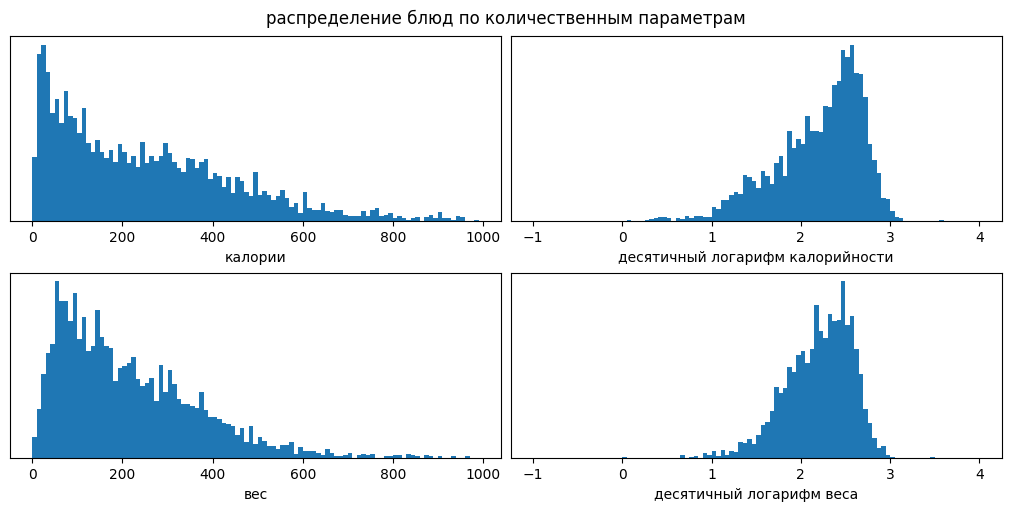

In [503]:
fig, axes = plt.subplots(2,2, figsize=(10,5), layout='constrained')
axes = axes.flatten()

axes[0].hist(dish_df.total_calories, bins=range(0,1000,10))
axes[1].hist(dish_df.total_calories.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])

axes[2].hist(dish_df.total_mass, bins=range(0,1000,10))
axes[3].hist(dish_df.total_mass.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])

for i in range(4): axes[i].set_yticks([])
axes[0].set_xlabel('калории')
axes[2].set_xlabel('вес')
axes[1].set_xlabel('десятичный логарифм калорийности')
axes[3].set_xlabel('десятичный логарифм веса')

fig.suptitle('распределение блюд по количественным параметрам')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* распределения ближе к логнормальным
* однако спешить переходить к логарифмам не стоит, так как в природе самих параметров заложена аддитивность по отношению к целевой переменной, а не мультипликативность. Поэтому есть надежда сделать более точный baseline на аддитивных параметрах

### посмотрим на частотность ингредиентов в блюдах

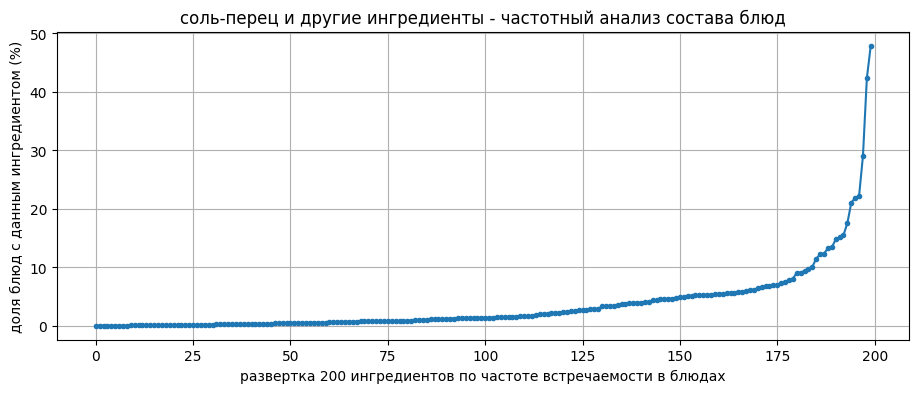

In [504]:
y = np.sort(V_ingr_ij.sum(axis=0)/len(dish_df)*100)    # делаем развертку по частоте
plt.figure(figsize=(11,4))
plt.plot(y, marker='.')
plt.ylabel('доля блюд с данным ингредиентом (%)')
plt.xlabel('развертка 200 ингредиентов по частоте встречаемости в блюдах')
plt.title('соль-перец и другие ингредиенты - частотный анализ состава блюд')
plt.grid()
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
как видим, компоненты вектора разномасштабные - не забыть про нормализацию!

# Baseline models

In [505]:
baseline = {}

## готовим данные

In [506]:
Xy = np.concatenate([dish_df[['total_calories','total_mass']].values, V_ingr_ij], axis=1)

Xy.shape

(3262, 202)

In [507]:
y = Xy[:,0]
X = Xy[:,1:]

X.shape, y.shape

((3262, 201), (3262,))

### нормализуем только предикторы

In [508]:
scaler_ml = StandardScaler()

X_norm = scaler_ml.fit_transform(X)

### разделяем трейн и тест выборки

In [509]:
X_test = X_norm[:(dish_df.split == 'test').sum()]        # мы сразу упорядочили dish_df по полю split
X_train = X_norm[(dish_df.split == 'test').sum():]

y_test = y[:(dish_df.split == 'test').sum()]
y_train = y[(dish_df.split == 'test').sum():]


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2755, 201), (2755,), (507, 201), (507,))

## линейная регрессия - Least Square Plane

In [510]:
baseline['linear'] = LinearRegression()
baseline['linear'].fit(X_train,y_train)
y_pred = baseline['linear'].predict(X_test)

print('Baseline model LR results on test data:')
print('MAE =', round(MAE(y_test, y_pred),2), 'калорий')
print('RMSE =', round(np.sqrt(MSE(y_test, y_pred)),2), 'калорий')
print('R2 =', round(R2(y_test, y_pred)*100,2), '%')

Baseline model LR results on test data:
MAE = 56.45 калорий
RMSE = 89.1 калорий
R2 = 82.34 %


**ВЫВОДЫ:**
* хоть мы значительно не дотягиваем до целевого MAE (50), линейная регрессия, как обычно, хороша интерпретацией результата: по факту, она дает нам в своих весах рецепты блюд - если нормировать их на суммарную калорийность total_calories, то веса прямо дадут нам ответ, сколько взять каждого ингредиента в калориях
* обычно мы измеряем ингредиенты в граммах - если взять за целевую переменную total_mass, то веса дадут количества ингредиентов в граммах

## ансамбли решающих деревьев - Histogram-based Gradient Boosting Regression Tree

In [511]:
baseline['HGBoost'] = HistGradientBoostingRegressor()
baseline['HGBoost'].fit(X_train,y_train)
y_pred = baseline['HGBoost'].predict(X_test)

print('Baseline model HGB results on test data:')
print('MAE =', round(MAE(y_test, y_pred),2), 'калорий')
print('RMSE =', round(np.sqrt(MSE(y_test, y_pred)),2), 'калорий')
print('R2 =', round(R2(y_test, y_pred)*100,2), '%')

Baseline model HGB results on test data:
MAE = 51.73 калорий
RMSE = 88.56 калорий
R2 = 82.56 %


**ВЫВОДЫ:**
* мы почти достигли целевого MAE (50) - без DL и без генерации DL-фич !
* фокус в том, что состав блюд по ингредиентам и вес - это уже сами по себе релевантные фичи для задачи калорийности
* более того, наша векторизация по id ингредиентов, по факту, является наиболее релевантной задаче семантической токинезацией текстового описания - вряд ли вектор с токинезаций и эмбеддингом по общеязыковому Word2Vec алгоритму будет более имманентен задаче.  Едиственно, что может добавить Word2Vec fkujhbnv к нашей векторизации по ингредиентам, - это учесть синонимы одного и того же ингредиента с близкой калорийностью - например, говядина и телятина, или курица и цыпленок, или булочка и хлеб, ну или сыграть на семантической аддитивности Word2Vec-векторов: типа, сэндвич коллинеарен (хлеб + ветчина + сыр).
* маловероятно, что DL-фичи, экстрактированные предобученными моделями из фото или текстового описания ингредиентов блюд, будут более релевантными задаче, чем уже использованные,  - в лучшем случае они добавят чуть больше дополнительной точности, чем привнесут шума!
* но мне уже просто интересно, сколько по-максимуму можно выжать из табличных фич и ингредиентной векторизации - поэтому попробуем еще один бейслайн - полносвязную нейронку с механизмами борьбы с переобучением на коротком датасете:  

## полносвязная нейронная сеть для регрессии - MLP regressor

### собираем загрузчик данных

In [512]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), 
                             torch.tensor(y_test, dtype=torch.float32).unsqueeze(1))

In [513]:
train_loader = DataLoader( train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader( test_dataset, batch_size=32, shuffle=False)

### собираем архитектуру сети

In [514]:
input_size = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(p=0.1),

    nn.Linear(64, 1)
)

### функцию потерь берем по метрике, по которой задан порог обучения

In [515]:

criterion = nn.L1Loss()                  # MAE

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### цикл обучения минибатчами

In [516]:
epochs_history = []
nof_epochs = 401                            # обучение происходит очень быстро даже на CPU - данные маленькие
best_MAE = 250

for epoch in range(nof_epochs):
    running_train_loss = 0.0
    running_val_loss = 0.0

    model.train()
    counter = 0
    for X_batch, y_batch in train_loader:
        
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss
        counter += 1
    
    avg_train_loss = (running_train_loss / counter).item()

    model.eval()
    counter = 0
    for X_batch, y_batch in test_loader:
        
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        running_val_loss += loss
        counter += 1
    
    avg_val_loss = (running_val_loss / counter).item()

    if best_MAE > avg_val_loss:
        best_MAE = avg_val_loss

    if epoch % 20 == 0:
        epochs_history.append( [epoch, avg_train_loss, avg_val_loss])
        print('Epoch No', str(epoch).rjust(3), 
              ' |  Train MAE =', round(avg_train_loss,2), 
              ' |  Validation MAE =', round(avg_val_loss,2))
        
print('='*70)
print('Best MAE reached =', best_MAE)

Epoch No   0  |  Train MAE = 255.1  |  Validation MAE = 255.42
Epoch No  20  |  Train MAE = 216.97  |  Validation MAE = 217.13
Epoch No  40  |  Train MAE = 125.14  |  Validation MAE = 129.69
Epoch No  60  |  Train MAE = 38.21  |  Validation MAE = 58.55
Epoch No  80  |  Train MAE = 29.12  |  Validation MAE = 49.18
Epoch No 100  |  Train MAE = 27.48  |  Validation MAE = 45.78
Epoch No 120  |  Train MAE = 25.08  |  Validation MAE = 44.23
Epoch No 140  |  Train MAE = 25.84  |  Validation MAE = 44.46
Epoch No 160  |  Train MAE = 22.95  |  Validation MAE = 43.13
Epoch No 180  |  Train MAE = 25.31  |  Validation MAE = 42.71
Epoch No 200  |  Train MAE = 24.19  |  Validation MAE = 42.68
Epoch No 220  |  Train MAE = 23.72  |  Validation MAE = 43.74
Epoch No 240  |  Train MAE = 22.25  |  Validation MAE = 43.07
Epoch No 260  |  Train MAE = 23.28  |  Validation MAE = 42.26
Epoch No 280  |  Train MAE = 21.62  |  Validation MAE = 42.66
Epoch No 300  |  Train MAE = 21.68  |  Validation MAE = 41.68
Epo

### визуализация обучения по эпохам

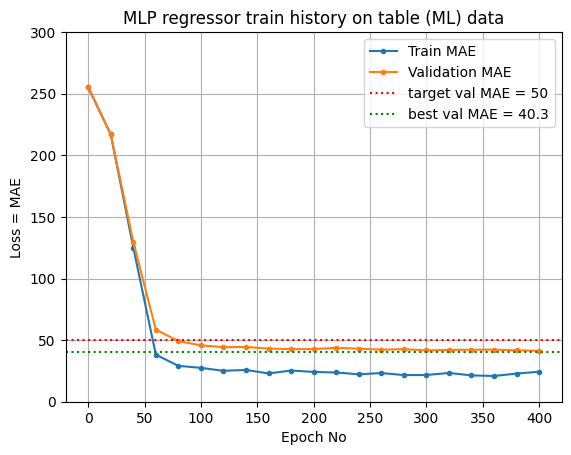

In [517]:
loss_history = np.array(epochs_history)

plt.plot(loss_history[:,0], loss_history[:,1], marker='.', label='Train MAE')
plt.plot(loss_history[:,0], loss_history[:,2], marker='.', label='Validation MAE')
plt.axhline(50, color='red', ls=':', label='target val MAE = 50')
plt.axhline(best_MAE, color='green', ls=':', label='best val MAE = '+ str(round(best_MAE,1)))
plt.ylim(0,300)
plt.grid()
plt.legend()
plt.title('MLP regressor train history on table (ML) data')
plt.xlabel('Epoch No')
plt.ylabel('Loss = MAE')
plt.show()

## ВЫВОДЫ ПО BASELINE МОДЕЛЯМ:
* когнитивные способности одержали верх над комбинаторными - лучшая baseline модель получилась на основе скромного перцептрона с двумя скрытыми слоями и (201 + 1) * 256 + (256 + 1) * 64 + 64 + 1 = 68225 параметрами: она достигла уровня МАЕ=40 без использования DL-фич, обычным табличным ML:
  * Линейная регрессия MAE = 56
  * GBoost ансамбли MAE = 52
  * Полносвязная NN MAE = 41 +/- 2
* устранить флуктуации точности MLP-модели принципиально нельзя, так как это оборотная сторона механизмов удержания модели от переобучения - мы включили финальный dropout на 64 нейрона перед выходным слоем
* для максимального уменьшения флуктуаций асимптотической точности обучения мы увеличили размеры (мини)батча и снизили вероятность dropout.  Уменьшение шага обучения только ухудшает асимптотическую точность не снижая флуктуации, но замедляя скорость обучение - видимо, малый шаг мешает выскакивать траектории обучения из локальных экстремумов 
* снижать флуктуации асимптотической точности еще ниже не имеет смысла, так как у валидационной выборки также есть ограничения ее репрезентативности при размерах в 507 объектов.  Предельную сигму влияния отклонения валидационной выборки от репрезентативности можно грубо оценить как 41 / sqrt(507) = 1.8 - это наши уже достигнутые +/- 2 флуктуации

# Дальнейший план по DL-обучению
* будем использовать предобученные DL модели (NLP и CV) как дополнительные feature-extractor-ы:
  * для текстового описания возьмем обученный текстовый эмбеддинг с семантической векторизацией
  * для фото используем готовую сетку из torch-vision, которую уже успешно опробовали в проекте стрима 3
* далее конкатенируем все три вектора фич в общий и опять применим полносвязную сеть, которую обучим сами.
* кажется, что можно возразить против такого подхода: но где же аугментация изображений внутри дата-лодера, без которой, как известно, хорошо обучить сверточные слои невозможно.  Однако, мы и не собираемся дообучать сверточные слои - мы собираемся переиспользовать обученные модели как генераторы финальных фич - то есть, если предобучение сверточных слоев (на аугментированных данных) прошло удачно, финальные фичи уже не зависят от аугментации - они должны давать приблизительно один и тот же вектор фич для всех аугментаций одного и того же изображения
* все решит эксперимент - посмотрим что получится при нашем подходе - тем более, что в реалиях моей работы он куда более практичен для применения полученных на курсе знаний, чем амбициозное full-multimodal переобучение, для которого и платформ-то в наличии нет!

# Этап 2. Генерация мультимодальных фич, подготовка датасета и батчевого загрузчика

## NLP-features generation

In [518]:
# загружаем веса текстовой модели
google_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True) 


In [519]:
text_list = list(dish_df.descr.map(lambda s: s.replace('(','').replace(')','').split()))

V_w2v = []
for i in range(len(dish_df)):
    V_w2v.append(get_text_embedding(text_list[i], w2v_model=google_model))

V_w2v = np.array(V_w2v)

V_w2v.shape, V_w2v.dtype, type(V_w2v)

((3262, 300), dtype('float32'), numpy.ndarray)

In [520]:
scaler_w2v = StandardScaler()

V_w2v_norm = scaler_w2v.fit_transform(V_w2v)

## CV-features generation

In [521]:
cv_weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1

cv_model = mobilenet_v3_small(weights=cv_weights)

cv_model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [522]:
f_name = 'rgb.png'
cv_preprocess = cv_weights.transforms()    # возьмем предобработку из загруженной модели

V_cv = []
for i in tqdm(range(len(dish_df))):

    img = Image.open(os.path.join(dataset_dir, 'images', dish_df.dish_id[i], f_name)).convert("RGB")
    x = cv_preprocess(img).unsqueeze(0)

    with torch.no_grad():
        f = cv_model.features(x)
        f = cv_model.avgpool(f)
        f = torch.flatten(f, 1)[0].detach().numpy()
    
    V_cv.append(f)
    
V_cv = np.array(V_cv)

V_cv.shape, V_cv.dtype, type(V_cv)

100%|██████████| 3262/3262 [01:00<00:00, 54.14it/s]


((3262, 576), dtype('float32'), numpy.ndarray)

In [523]:
scaler_cv = StandardScaler()

V_cv_norm = scaler_cv.fit_transform(V_cv)

## конкатенируем все группы фич и разделяем на train-test

In [524]:
#X_DL = np.concatenate([X_norm.astype(np.float32), V_w2v_norm, V_cv_norm], axis=1)
X_DL = np.concatenate([X_norm.astype(np.float32)[:,:1], V_w2v_norm, V_cv_norm], axis=1)  # из ML-фич оставляем массу блюда

X_DL.shape

(3262, 877)

In [525]:
X_test = X_DL[:(dish_df.split == 'test').sum()]        # мы сразу упорядочили dish_df по полю split
X_train = X_DL[(dish_df.split == 'test').sum():]

#y_test = y[:(dish_df.split == 'test').sum()]          # эти остались прежними
#y_train = y[(dish_df.split == 'test').sum():]


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2755, 877), (2755,), (507, 877), (507,))

## собираем загрузчик данных

In [526]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), 
                             torch.tensor(y_test, dtype=torch.float32).unsqueeze(1))

In [527]:
train_loader = DataLoader( train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader( test_dataset, batch_size=32, shuffle=False)

# Этап 3. Обучение модели

## собираем архитектуру модели

In [ ]:
input_size = X_train.shape[1]

model_dl = nn.Sequential(
    nn.Linear(input_size, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),

    nn.Linear(1024, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(128, 1)
)

## функцию потерь берем по метрике, по которой задан порог обучения

In [ ]:
criterion = nn.L1Loss()                  # MAE

optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.001)

## цикл обучения минибатчами

In [ ]:
epochs_history_dl = []
nof_epochs = 401                            # обучение происходит очень быстро даже на CPU - данные маленькие
best_MAE_dl = 250

for epoch in range(nof_epochs):
    running_train_loss = 0.0
    running_val_loss = 0.0

    model_dl.train()
    counter = 0
    for X_batch, y_batch in train_loader:
        
        pred = model_dl(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss
        counter += 1
    
    avg_train_loss = (running_train_loss / counter).item()

    model_dl.eval()
    counter = 0
    for X_batch, y_batch in test_loader:
        
        pred = model_dl(X_batch)
        loss = criterion(pred, y_batch)
        running_val_loss += loss
        counter += 1
    
    avg_val_loss = (running_val_loss / counter).item()

    if best_MAE_dl > avg_val_loss:
        best_MAE_dl = avg_val_loss

    if epoch % 20 == 0:
        epochs_history_dl.append( [epoch, avg_train_loss, avg_val_loss])
        print('Epoch No', str(epoch).rjust(3), 
              ' |  Train MAE =', round(avg_train_loss,2), 
              ' |  Validation MAE =', round(avg_val_loss,2))
        
print('='*70)
print('Best MAE reached =', best_MAE_dl)

Epoch No   0  |  Train MAE = 254.69  |  Validation MAE = 255.0
Epoch No  20  |  Train MAE = 180.85  |  Validation MAE = 181.45
Epoch No  40  |  Train MAE = 45.84  |  Validation MAE = 57.13
Epoch No  60  |  Train MAE = 32.28  |  Validation MAE = 51.67
Epoch No  80  |  Train MAE = 30.61  |  Validation MAE = 53.51
Epoch No 100  |  Train MAE = 29.38  |  Validation MAE = 48.15
Epoch No 120  |  Train MAE = 29.44  |  Validation MAE = 50.47
Epoch No 140  |  Train MAE = 29.48  |  Validation MAE = 49.81
Epoch No 160  |  Train MAE = 30.52  |  Validation MAE = 48.41
Epoch No 180  |  Train MAE = 29.5  |  Validation MAE = 49.63
Epoch No 200  |  Train MAE = 27.96  |  Validation MAE = 50.59
Epoch No 220  |  Train MAE = 25.59  |  Validation MAE = 47.34
Epoch No 240  |  Train MAE = 27.9  |  Validation MAE = 51.47
Epoch No 260  |  Train MAE = 26.03  |  Validation MAE = 49.09
Epoch No 280  |  Train MAE = 29.37  |  Validation MAE = 48.98
Epoch No 300  |  Train MAE = 29.81  |  Validation MAE = 48.66
Epoch N

## визуализация обучения по эпохам

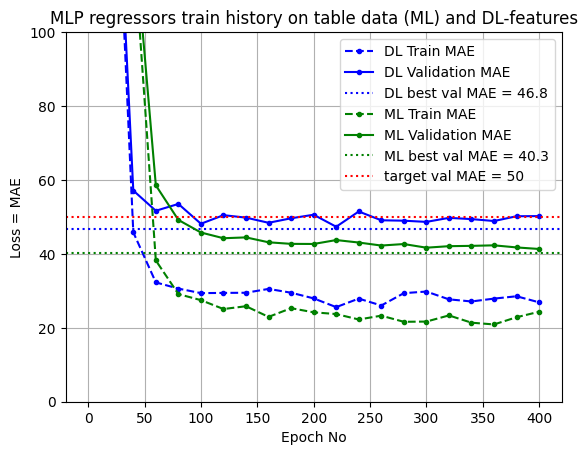

In [539]:
loss_history_dl = np.array(epochs_history_dl)

plt.plot(loss_history_dl[:,0], loss_history_dl[:,1], marker='.', color='blue', ls='--', label='DL Train MAE')
plt.plot(loss_history_dl[:,0], loss_history_dl[:,2], marker='.', color='blue', label='DL Validation MAE')
plt.axhline(best_MAE_dl, color='blue', ls=':', label='DL best val MAE = '+ str(round(best_MAE_dl,1)))

plt.plot(loss_history[:,0], loss_history[:,1], marker='.', color='green', ls='--', label='ML Train MAE')
plt.plot(loss_history[:,0], loss_history[:,2], marker='.', color='green', label='ML Validation MAE')
plt.axhline(best_MAE, color='green', ls=':', label='ML best val MAE = '+ str(round(best_MAE,1)))

plt.axhline(50, color='red', ls=':', label='target val MAE = 50')

plt.ylim(0,100)
plt.grid()
plt.legend()
plt.title('MLP regressors train history on table data (ML) and DL-features')
plt.xlabel('Epoch No')
plt.ylabel('Loss = MAE')
plt.show()